# S4 — 時間序列 + EDA 實戰

> **時間**：2 小時  
> **資料**：`orders_enriched.csv`（S3 產出）  
> **學完能幹嘛**：回答老闆「這幾個月業績怎麼樣？」「下個月該不該進貨？」「哪個品類相關性最強？」

---

## 上節回顧 + 本節為什麼重要

S3 我們合併了三表、算出各地區 Top 商品。但真實的商業問題都有**時間維度**：

- 哪個**月**營收最高？
- 過去 7 天的**趨勢**是往上還是往下？
- 每個**星期幾**的銷售有差嗎？
- 品類之間的銷售有**相關性**嗎？

這些都是**時間序列分析 (Time Series)** 和 **探索式分析 (EDA)** 的核心問題。

> **DA 視角**：EDA 是所有資料分析的第一步，目的是「先看懂資料、再做決策」。


In [9]:
import pandas as pd
import numpy as np

df = pd.read_csv(
    '../datasets/ecommerce/orders_enriched.csv',
    parse_dates=['order_date'],
)
print('資料形狀:', df.shape)
print('日期範圍:', df['order_date'].min(), '~', df['order_date'].max())
df.head(3)

資料形狀: (188, 14)
日期範圍: 2025-01-02 00:00:00 ~ 2025-12-31 00:00:00


,order_id,customer_id,product_id,qty,order_date,amount,customer_name,region,signup_date,vip_level,product_name,category,unit_price,stock_qty
0,5064,2022,1026,4.0,2025-03-26,8600.0,Victor Lin,North,2023-02-27,Gold,Dumbbell 5kg,Sports,2150,51
1,5023,2026,1021,5.0,2025-01-05,1355.0,Zoe Huang,South,2023-05-16,Platinum,Throw Pillow,Home,271,150
2,5123,2013,1013,2.0,2025-09-11,NaN,Mia Huang,North,2023-07-17,Platinum,Cotton T-Shirt,Clothing,1769,174


In [30]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))
from common.checker import check

---
## 核心觀念 1／3 — 日期操作：`to_datetime` 與 `.dt` accessor

一旦把欄位轉成 datetime 型別，就能用 `.dt` 快速拆出年、月、日、星期。


In [31]:
# 從 order_date 拆出常用的時間欄位
df['year']     = df['order_date'].dt.year
df['month']    = df['order_date'].dt.month
df['weekday']  = df['order_date'].dt.day_name()   # Monday, Tuesday, ...
df['year_mon'] = df['order_date'].dt.to_period('M')  # 2025-01, 2025-02, ...

df[['order_date', 'year', 'month', 'weekday', 'year_mon']].head()

,order_date,year,month,weekday,year_mon
0,2025-03-26,2025,3,Wednesday,2025-03
1,2025-01-05,2025,1,Sunday,2025-01
2,2025-09-11,2025,9,Thursday,2025-09
3,2025-05-22,2025,5,Thursday,2025-05
4,2025-08-20,2025,8,Wednesday,2025-08


**口訣**：`.dt.年/月/日/星期/週數/季度`，像 Excel 的 `YEAR() MONTH()` 一樣好用。


---
## 核心觀念 2／3 — `resample`：時間重新取樣

`resample` 是專門給時序資料做「重新切粒度」的工具。例如：
- 原本每筆訂單 → 重取樣成「每日總和」「每月總和」「每週平均」

**前提**：index 必須是 datetime。


In [32]:
ts.head(20)

,order_id,customer_id,product_id,qty,amount,customer_name,region,signup_date,vip_level,product_name,category,unit_price,stock_qty,year,month,weekday,year_mon
order_date,,,,,,,,,,,,,,,,,
2025-01-02,5157,2005,1026,5.0,10750.0,Emma Liu,West,2023-05-18,Bronze,Dumbbell 5kg,Sports,2150,51,2025,1,Thursday,2025-01
2025-01-02,5012,2002,1006,4.0,628.0,Bob Wang,West,2023-07-14,Gold,Power Bank,Electronics,157,47,2025,1,Thursday,2025-01
2025-01-02,5119,2026,1017,3.0,942.0,Zoe Huang,South,2023-05-16,Platinum,Cap,Clothing,314,176,2025,1,Thursday,2025-01
2025-01-05,5020,2015,1011,1.0,1506.0,Olivia Huang,North,2023-12-15,Bronze,Statistics 101,Books,1506,3,2025,1,Sunday,2025-01
2025-01-05,5023,2026,1021,5.0,1355.0,Zoe Huang,South,2023-05-16,Platinum,Throw Pillow,Home,271,150,2025,1,Sunday,2025-01
2025-01-07,5076,2017,1021,3.0,813.0,Quinn Chen,East,2023-08-11,Silver,Throw Pillow,Home,271,150,2025,1,Tuesday,2025-01
2025-01-12,5136,2010,1023,3.0,4431.0,Jack Liu,South,2023-03-12,Platinum,Wall Clock,Home,1477,35,2025,1,Sunday,2025-01
2025-01-15,5176,2022,1027,3.0,3000.0,Victor Lin,North,2023-02-27,Gold,Running Shoes,Sports,1000,232,2025,1,Wednesday,2025-01
2025-01-16,5069,2003,1025,3.0,1951.0,Carol Huang,South,2023-12-17,Gold,Yoga Mat,Sports,1951,40,2025,1,Thursday,2025-01


In [33]:
# 把 order_date 設為 index
ts = df.set_index('order_date').sort_index() # time series 的 index 必須是時間，並且要排序

# 月度營收（'ME' = Month End）
monthly = ts['amount'].resample('ME').sum() # time series 選amount 欄位，然後以月末為頻率重取樣，最後求和
print('📅 月度營收:')
print(monthly)

# 季度營收（'ME' = Month End）
quarterly = ts['amount'].resample('QE').sum() # time series 選amount 欄位，然後以月末為頻率重取樣，最後求和
print('📅 季度營收:')
print(quarterly)

📅 月度營收:
order_date
2025-01-31    58525.0
2025-02-28    50171.0
2025-03-31    55920.0
2025-04-30    44665.0
2025-05-31    31674.0
2025-06-30    46031.0
2025-07-31    34648.0
2025-08-31    60846.0
2025-09-30    47207.0
2025-10-31    65472.0
2025-11-30    56908.0
2025-12-31    42889.0
Freq: ME, Name: amount, dtype: float64
📅 季度營收:
order_date
2025-03-31    164616.0
2025-06-30    122370.0
2025-09-30    142701.0
2025-12-31    165269.0
Freq: QE-DEC, Name: amount, dtype: float64


In [5]:
df.head(2)

,order_id,customer_id,product_id,qty,order_date,amount,customer_name,region,signup_date,vip_level,product_name,category,unit_price,stock_qty,year,month,weekday,year_mon
0,5064,2022,1026,4.0,2025-03-26,8600.0,Victor Lin,North,2023-02-27,Gold,Dumbbell 5kg,Sports,2150,51,2025,3,Wednesday,2025-03
1,5023,2026,1021,5.0,2025-01-05,1355.0,Zoe Huang,South,2023-05-16,Platinum,Throw Pillow,Home,271,150,2025,1,Sunday,2025-01


In [6]:
df.set_index('order_date', inplace=True)

In [34]:
# 每週訂單數（'W' = Week）
weekly_count = ts['order_id'].resample('W').count()
print('📅 每週訂單數（前 8 週）:')
print(weekly_count.head(8))

📅 每週訂單數（前 8 週）:
order_date
2025-01-05    5
2025-01-12    2
2025-01-19    3
2025-01-26    5
2025-02-02    2
2025-02-09    5
2025-02-16    5
2025-02-23    3
Freq: W-SUN, Name: order_id, dtype: int64


**常用 resample 粒度**：`'D'` 日、`'W'` 週、`'ME'` 月底、`'QE'` 季末、`'YE'` 年底。


---
## 核心觀念 3／3 — `rolling`：移動平均（平滑雜訊）

日資料常有大起大落的雜訊，**移動平均**能平滑趨勢、看出大方向。


In [35]:
daily = ts['amount'].resample('D').sum()        # 每日營收
ma7 = daily.rolling(window=7).mean()          # 7 日移動平均

compare = pd.DataFrame({
    '每日原值': daily,
    'MA7':     ma7,
}).dropna()

print('📈 7 日移動平均（前 10 天）:')
print(compare.head(10).round(0))

📈 7 日移動平均（前 10 天）:
              每日原值     MA7
order_date                
2025-01-08     0.0  2285.0
2025-01-09     0.0   525.0
2025-01-10     0.0   525.0
2025-01-11     0.0   525.0
2025-01-12  4431.0   749.0
2025-01-13     0.0   749.0
2025-01-14     0.0   633.0
2025-01-15  3000.0  1062.0
2025-01-16  1951.0  1340.0
2025-01-17     0.0  1340.0


<Axes: xlabel='order_date'>

C:\Users\student\AppData\Roaming\Python\Python312\site-packages\IPython\core\events.py:100: UserWarning: Glyph 27599 (\N{CJK UNIFIED IDEOGRAPH-6BCF}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
C:\Users\student\AppData\Roaming\Python\Python312\site-packages\IPython\core\events.py:100: UserWarning: Glyph 26085 (\N{CJK UNIFIED IDEOGRAPH-65E5}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
C:\Users\student\AppData\Roaming\Python\Python312\site-packages\IPython\core\events.py:100: UserWarning: Glyph 21407 (\N{CJK UNIFIED IDEOGRAPH-539F}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
C:\Users\student\AppData\Roaming\Python\Python312\site-packages\IPython\core\events.py:100: UserWarning: Glyph 20540 (\N{CJK UNIFIED IDEOGRAPH-503C}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
C:\Users\student\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 27599 (\N{CJK UNIFIED IDEOGRAPH-6BCF}) missing from f

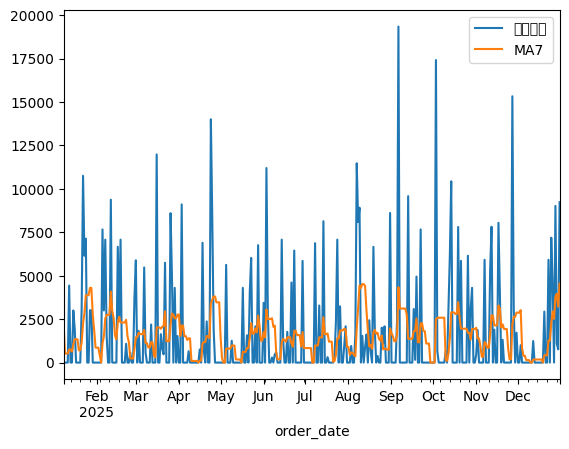

In [ ]:
import matplotlib.pyplot as plt

compare.plot()

In [19]:
daily.rolling(window=7).mean().head(15)

order_date
2025-01-02            NaN
2025-01-03            NaN
2025-01-04            NaN
2025-01-05            NaN
2025-01-06            NaN
2025-01-07            NaN
2025-01-08    2284.857143
2025-01-09     524.857143
2025-01-10     524.857143
2025-01-11     524.857143
2025-01-12     749.142857
2025-01-13     749.142857
2025-01-14     633.000000
2025-01-15    1061.571429
2025-01-16    1340.285714
Freq: D, Name: amount, dtype: float64

**口訣**：`.rolling(window=N).mean()` → 滑動窗口平均，N 越大越平滑。


---
## EDA 三大招：describe、corr、value_counts

拿到任何資料，花 5 分鐘做這三件事就能對資料有基本認識。


> ### 💡 知識補給站 — EDA 系統化清單
> 
> EDA 不是隨便看看，有一份**系統化清單**可以確保不遺漏：
> 
> | 步驟 | 做什麼 | 工具 |
> |---|---|---|
> | 1. 形狀與型別 | 幾列幾欄？型別對嗎？ | `shape`, `dtypes`, `info()` |
> | 2. 缺值地圖 | 哪些欄位缺最多？ | `isna().sum()`, `isna().mean()` |
> | 3. 數值摘要 | min/max 合理嗎？有沒有離群值？ | `describe()` |
> | 4. 類別分布 | 有沒有拼寫錯誤或稀有類別？ | `value_counts()` |
> | 5. 相關性 | 哪些欄位高度相關？ | `corr()`（但記得：相關 ≠ 因果） |
> | 6. 時間趨勢 | 有沒有明顯的季節性或異常跳動？ | `resample().sum()` + 畫圖 |
> 
> 把這 6 步跑完，你就對資料有 **80% 的掌握**。
> 
> 延伸工具：`ydata-profiling`（原 pandas-profiling）— 一行指令就能產出完整 EDA 報告。
> 
> *延伸關鍵字：EDA checklist, exploratory data analysis, ydata-profiling, systematic analysis*

In [36]:
# 招 1: describe — 數值欄的統計摘要
print('📊 數值摘要:')
print(df[['qty', 'amount', 'unit_price', 'stock_qty']].describe().round(1))

📊 數值摘要:
         qty   amount  unit_price  stock_qty
count  188.0    164.0       188.0      188.0
mean     3.1   3627.8      1234.9      159.7
std      1.4   2879.3       723.1       82.5
min      1.0    157.0       157.0        3.0
25%      2.0   1343.2       474.0      102.8
50%      3.0   2967.5      1537.0      175.0
75%      4.0   5774.2      1846.0      219.2
max      5.0  11980.0      2396.0      287.0


In [37]:
# 招 2: value_counts — 類別欄的分布
print('🏷️  地區分布:')
print(df['region'].value_counts())
print('\n🏷️  品類分布:')
print(df['category'].value_counts())

🏷️  地區分布:
region
South    72
North    67
West     33
East     16
Name: count, dtype: int64

🏷️  品類分布:
category
Books          44
Sports         43
Clothing       39
Home           31
Electronics    31
Name: count, dtype: int64


In [38]:
# 招 3: 相關係數矩陣
num_cols = ['qty', 'amount', 'unit_price', 'stock_qty']
print('🔗 相關係數:')
print(df[num_cols].corr().round(2))

🔗 相關係數:
             qty  amount  unit_price  stock_qty
qty         1.00    0.50       -0.08      -0.06
amount      0.50    1.00        0.73      -0.08
unit_price -0.08    0.73        1.00      -0.03
stock_qty  -0.06   -0.08       -0.03       1.00


**解讀相關係數**：
- `1.0` 完美正相關 | `0` 無關 | `-1.0` 完美負相關
- `|r| > 0.7` 強相關 | `0.3~0.7` 中 | `< 0.3` 弱


> ### 💡 知識補給站 — Correlation ≠ Causation（相關不等於因果）
> 
> 剛才看到 `unit_price` 和 `amount` 的相關係數很高 — 但這**不代表**「提高單價就能增加營收」。
> 
> **經典反例**：冰淇淋銷量和溺水人數高度正相關 → 難道吃冰淇淋會溺水？不是！背後有**共同的隱藏變數 (confounding variable)**：夏天。天氣熱 → 買冰淇淋的人多 + 游泳的人多。
> 
> **在報告中**：
> - ✅ 安全的寫法：「A 與 B 呈正相關 (r = 0.85)」
> - ❌ 危險的寫法：「A **導致** B 增加」← 這需要**實驗**（如 A/B test）或進階統計方法才能證明
> 
> **因果推論**需要：控制實驗（A/B test）、工具變數（IV）、自然實驗、或 RCT — 這些是統計學和 ML 的進階主題。
> 
> *延伸關鍵字：correlation vs causation, confounding variable, A/B test, causal inference*

---
## 實務 Case — 銷售趨勢與洞察

**情境**：行銷總監要你在下次會議前提出三個發現：
1. 月度營收走勢 → **最旺的月份**是哪個？
2. 星期幾的銷售最好？
3. 哪個品類 × 地區組合最值得重點經營？


In [39]:
# Q1: 月度趨勢
monthly_rev = df.groupby('year_mon')['amount'].sum()
best = monthly_rev.idxmax()
print(f'📈 月度營收:')
print(monthly_rev)
print(f'\n🏆 最旺月份: {best} (NT$ {monthly_rev.max():,.0f})')

📈 月度營收:
year_mon
2025-01    58525.0
2025-02    50171.0
2025-03    55920.0
2025-04    44665.0
2025-05    31674.0
2025-06    46031.0
2025-07    34648.0
2025-08    60846.0
2025-09    47207.0
2025-10    65472.0
2025-11    56908.0
2025-12    42889.0
Freq: M, Name: amount, dtype: float64

🏆 最旺月份: 2025-10 (NT$ 65,472)


In [23]:
# Q2: 星期幾表現（並依自然順序排序）
week_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
weekday_rev = df.groupby('weekday')['amount'].sum().reindex(week_order)
print('📅 星期幾營收:')
print(weekday_rev)
print(f'\n🏆 最強: {weekday_rev.idxmax()}  🐌 最弱: {weekday_rev.idxmin()}')

📅 星期幾營收:
weekday
Monday        60389.0
Tuesday       89364.0
Wednesday     82341.0
Thursday     100744.0
Friday       100277.0
Saturday      85475.0
Sunday        76366.0
Name: amount, dtype: float64

🏆 最強: Thursday  🐌 最弱: Monday


In [24]:
# Q3: 地區 × 品類熱點矩陣
hot = df.pivot_table(
    index='category', columns='region', values='amount', aggfunc='sum', fill_value=0,
)
print('🔥 地區 × 品類 營收熱點:')
print(hot)

# 找出 Top 1 組合
stacked = hot.stack().sort_values(ascending=False)
print(f'\n🏆 最強組合: {stacked.index[0]} = NT$ {stacked.iloc[0]:,.0f}')

🔥 地區 × 品類 營收熱點:
region          East    North    South     West
category                                       
Books         9580.0  80292.0  49404.0  24124.0
Clothing      2396.0  39852.0  55277.0  15352.0
Electronics   5311.0  24837.0  31718.0  13283.0
Home         12153.0  30919.0  11681.0  15884.0
Sports       13922.0  46465.0  85009.0  27497.0

🏆 最強組合: ('Sports', 'South') = NT$ 85,009


> ### 💡 知識補給站 — 當心 Simpson's Paradox
> 
> 我們剛才看到「整體最強的品類 × 地區組合」，但如果**拆開不同時間段**看，結論可能完全反轉 — 這就是 **Simpson's Paradox**（辛普森悖論）。
> 
> **範例情境**：
> - 整體：A 品類營收 > B 品類 ✓
> - 但按季度拆開：**每一季 B 都贏 A** → 只是 A 在大季度有更多訂單，拉高了整體數字
> 
> **解法**：做分析時**多加一層 breakdown**（按時間、按地區、按客群），看看結論是否一致。
> 
> 口訣：「**整體趨勢 ≠ 分組趨勢，多切一刀才安心**」。
> 
> 這在醫學研究、A/B testing、商業分析中都是經典陷阱 — 聚合數據可以騙人。
> 
> *延伸關鍵字：Simpson's Paradox, ecological fallacy, stratified analysis, confounding variable*

In [ ]:
# 把分析結果存起來，S5/S6 視覺化直接拿去畫
monthly_rev.to_csv('../datasets/ecommerce/monthly_revenue.csv', header=['amount'])
print('已存 monthly_revenue.csv')

---
## 課堂練習（40 min）

### 🟢 送分題
1. 用 `df` 算出每個「月份 (1~12)」的平均訂單金額
2. 列出訂單數最多的前 3 天（日期）


In [46]:
# TODO
import pandas as pd
import numpy as np

df = pd.read_csv(
    '../datasets/ecommerce/orders_enriched.csv',
    parse_dates=['order_date'],
)

In [47]:
ts = df.set_index('order_date').sort_index()
ts['amount'].resample('ME').mean()


order_date
2025-01-31    3657.812500
2025-02-28    4180.916667
2025-03-31    3289.411765
2025-04-30    3722.083333
2025-05-31    3167.400000
2025-06-30    3540.846154
2025-07-31    3464.800000
2025-08-31    2645.478261
2025-09-30    5245.222222
2025-10-31    5036.307692
2025-11-30    3347.529412
2025-12-31    3574.083333
Freq: ME, Name: amount, dtype: float64

In [49]:
ts['order_id'].resample('D').count().sort_values(ascending=False).head(3)


order_date
2025-10-03    3
2025-08-25    3
2025-08-09    3
Name: order_id, dtype: int64

### 🟡 核心題
1. 計算**每月訂單數**的 3 個月移動平均
2. 找出 **2025 年第 4 季 (10~12 月)** 的總營收
3. 算出每個品類的訂單金額**中位數**並排序


In [ ]:
# TODO
ts['order_id'].resample('ME').count().rolling(window=3, center=True).mean().head(15)



order_date
2025-03-31    164616.0
2025-06-30    122370.0
2025-09-30    142701.0
2025-12-31    165269.0
Freq: QE-DEC, Name: amount, dtype: float64

In [52]:
ts['amount'].resample('QE').sum()

order_date
2025-03-31    164616.0
2025-06-30    122370.0
2025-09-30    142701.0
2025-12-31    165269.0
Freq: QE-DEC, Name: amount, dtype: float64

In [55]:
list(ts['amount'].resample('QE').sum())[-1]

165269.0

### 🔴 挑戰題
做一份「月度經營報告」，每月一列，包含：
- 總訂單數
- 總營收
- 活躍顧客數（`nunique`）
- 客單價（= 總營收 / 總訂單數）
- 與上月的營收成長率 (%)（提示：`.pct_change()`）

> 這張表就是真實 DA 每月都要交的**月報表**範本。


In [ ]:
# TODO

print(df.shape[0])
# sum(list(df['order_id'].value_counts()))


print(df['amount'].sum())

print()

188
594956.0


In [ ]:
# 🏁 大地遊戲 — Q4 總營收是多少？答對就能找到解答！
check('S4', round(q4_revenue))

---
## 小結與速查表

| 想做什麼 | 怎麼寫 |
|---|---|
| 轉日期 | `pd.to_datetime(col)` |
| 取年月日 | `.dt.year / .dt.month / .dt.day_name()` |
| 轉年月字串 | `.dt.to_period('M')` |
| 每日/週/月聚合 | `.resample('D'/'W'/'ME').sum()` |
| 移動平均 | `.rolling(window=7).mean()` |
| 成長率 | `.pct_change()` |
| 數值摘要 | `df.describe()` |
| 類別分布 | `df['x'].value_counts()` |
| 相關係數 | `df[num_cols].corr()` |
| Unique 計數 | `.nunique()` |

**下節預告 S5**：我們已經有了一大堆洞察數字，但**「數字不會說話，圖會」**。S5 教你 5 種必懂的視覺化圖，把今天算出來的結果變成一份能交給老闆的簡報。
